
# Traffic Flow Prediction Project

## Brief Summary
**Aim:** To accurately predict the volume of traffic (number of vehicles) at specific junctions based on historical time-series data.

**Objectives:**
1. Preprocess historical traffic data by extracting temporal features.
2. Implement multiple baseline Regression Models (Linear Regression, Ridge, SVR).
3. Implement advanced Ensemble Methods (Random Forest, Gradient Boosting, XGBoost).
4. Evaluate and compare models based on error metrics (MSE, RMSE, MAE, R²).
5. Analyze model performance, training complexity, and generalization capabilities.

**Problem Statement:**
Traffic congestion leads to economic loss and environmental pollution. Accurately predicting traffic flow allows city planners and commuters to optimize routes and manage infrastructure proactively. The challenge is to capture non-linear patterns and temporal dependencies in traffic data.

**Methodology:**
1. **Data Preprocessing**: Extract datetime features (hour, day, month, dayofweek) and drop irrelevant columns.
2. **Exploratory Data Analysis (EDA)**: Visualize trends and correlations.
3. **Modeling Task 2 (Regression)**: Train baseline models using continuous target variable (Vehicles).
4. **Modeling Task 5 (Ensembles)**: Train ensemble tree-based models to capture non-linearities.
5. **Evaluation Task 6**: Compare models computationally and statistically.


In [1]:

%pip install pandas numpy matplotlib seaborn scikit-learn xgboost


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Data Loading & Preprocessing

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# Load Data
df = pd.read_csv("../dataset/traffic.csv")

# Preprocessing
df['DateTime'] = pd.to_datetime(df['DateTime'])
df['year'] = df['DateTime'].dt.year
df['month'] = df['DateTime'].dt.month
df['day'] = df['DateTime'].dt.day
df['hour'] = df['DateTime'].dt.hour
df['dayofweek'] = df['DateTime'].dt.dayofweek
df.drop('DateTime', axis=1, inplace=True)

if 'ID' in df.columns:
    df.drop('ID', axis=1, inplace=True)

# Train-Test Split
X = df.drop('Vehicles', axis=1)
y = df['Vehicles']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


Training Data Shape: (38496, 6)
Testing Data Shape: (9624, 6)



## Task 2: Implement Regression Models
- Implement at least 2 regression algorithms (including SVR)
- Train on continuous target
- Evaluate using MSE, RMSE, MAE, R2
- Plot Actual vs Predicted (Done in Task 6 Evaluation)


In [3]:

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

results_dict = {}

def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    start_time = time.time()
    
    # If SVR, we might want to sample the training data slightly if it's too huge, 
    # but here we will train on full data to be thorough. 
    # SVR takes a while, so printing a message first.
    if name == 'SVR':
        print("Training SVR (this may take a few minutes)...")
        
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    
    results_dict[name] = {
        'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2 Score': r2, 'Train Time (s)': train_time, 'Predictions': pred
    }
    print(f"--- {name} ---")
    print(f"Train Time: {train_time:.4f} seconds")
    print(f"R2 Score: {r2:.4f}\n")
    return model

# 1. Linear Regression
lr = evaluate_model("Linear Regression", LinearRegression(), X_train, y_train, X_test, y_test)

# 2. Ridge Regression
ridge = evaluate_model("Ridge Regression", Ridge(alpha=1.0), X_train, y_train, X_test, y_test)

# 3. SVR (Support Vector Regression) with StandardScaler
svr = evaluate_model("SVR", make_pipeline(StandardScaler(), SVR(C=1.0, epsilon=0.2, cache_size=1000)), X_train, y_train, X_test, y_test)


--- Linear Regression ---
Train Time: 0.0247 seconds
R2 Score: 0.5997

--- Ridge Regression ---
Train Time: 0.0326 seconds
R2 Score: 0.5997

Training SVR (this may take a few minutes)...


--- SVR ---
Train Time: 36.2832 seconds
R2 Score: 0.8673




## Task 5: Implement Ensemble Methods
- Apply at least 2 ensemble techniques
- Compare against base learners
- Visualize feature importance


In [4]:

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

# 1. Random Forest
rf = evaluate_model("Random Forest", RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1), X_train, y_train, X_test, y_test)

# 2. Gradient Boosting
gb = evaluate_model("Gradient Boosting", GradientBoostingRegressor(n_estimators=100, random_state=42), X_train, y_train, X_test, y_test)

# 3. XGBoost
xgb = evaluate_model("XGBoost", XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1), X_train, y_train, X_test, y_test)


--- Random Forest ---
Train Time: 0.3564 seconds
R2 Score: 0.9641



--- Gradient Boosting ---
Train Time: 1.3906 seconds
R2 Score: 0.9017



--- XGBoost ---
Train Time: 0.2744 seconds
R2 Score: 0.9409



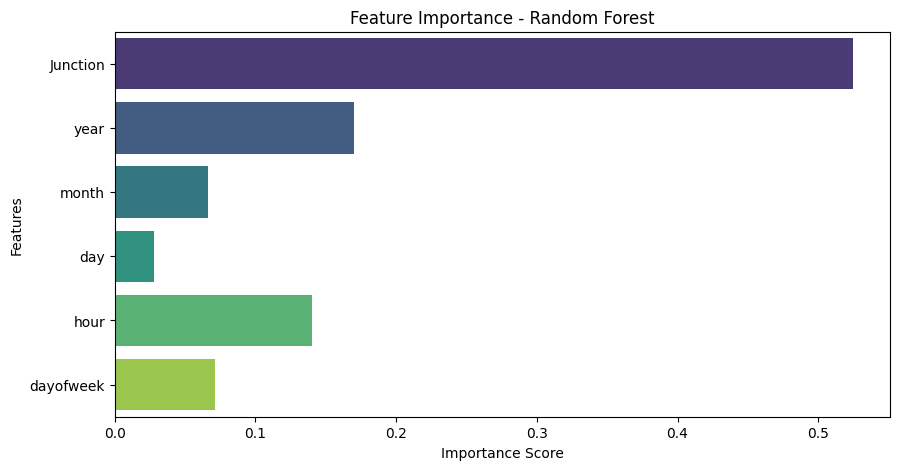

In [5]:

# Visualize feature importance for tree-based ensemble models (Random Forest)
plt.figure(figsize=(10, 5))
importance = rf.feature_importances_
sns.barplot(x=importance, y=X.columns, palette="viridis")
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()



## Task 6: Analysis, Comparison and Conclusions
- Compare Accuracy / Error metrics
- Training time and computational complexity
- Generalization (Overfitting vs Underfitting)


,MSE,RMSE,MAE,R2 Score,Train Time (s)
Random Forest,14.612851,3.822676,2.500123,0.964144,0.356427
XGBoost,24.072372,4.906360,2.893921,0.940933,0.274376
Gradient Boosting,40.061116,6.329385,4.011521,0.901702,1.390618
SVR,54.061122,7.352627,4.372276,0.867350,36.283245
Ridge Regression,163.123751,12.771991,9.637514,0.599742,0.032558
Linear Regression,163.124844,12.772034,9.637676,0.599740,0.024666


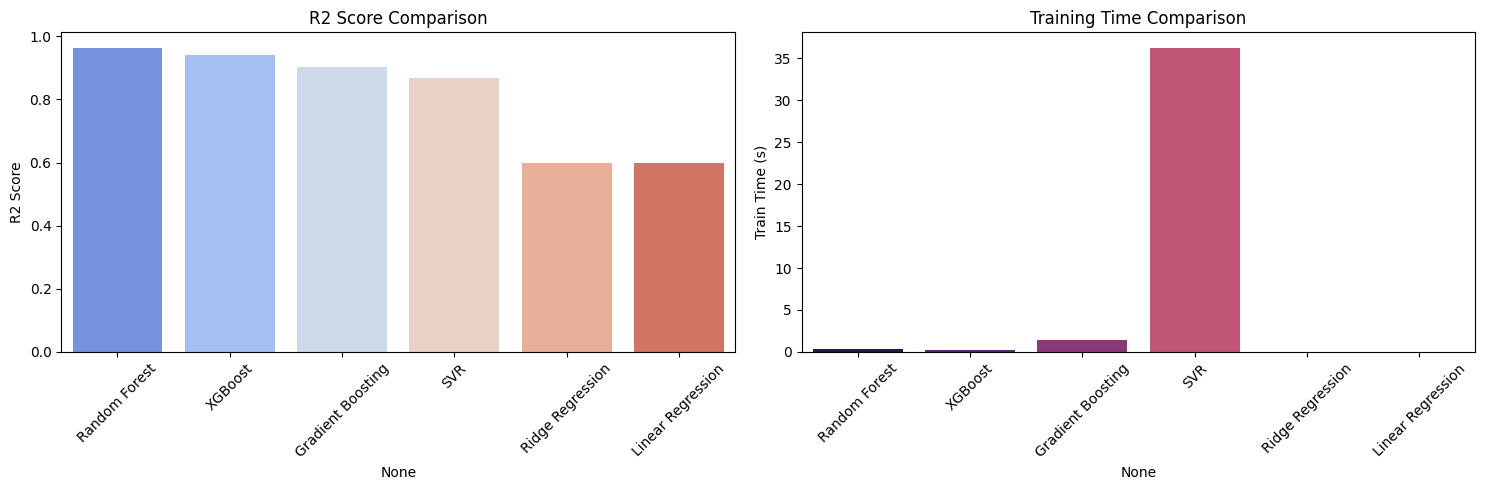

In [6]:

# Compile Results
results_df = pd.DataFrame.from_dict({k: {k2: v2 for k2, v2 in v.items() if k2 != 'Predictions'} for k, v in results_dict.items()}, orient='index')
results_df = results_df.sort_values(by='R2 Score', ascending=False)
display(results_df)

# Plot Metrics Comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(x=results_df.index, y='R2 Score', data=results_df, ax=axes[0], palette="coolwarm")
axes[0].set_title('R2 Score Comparison')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(x=results_df.index, y='Train Time (s)', data=results_df, ax=axes[1], palette="magma")
axes[1].set_title('Training Time Comparison')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


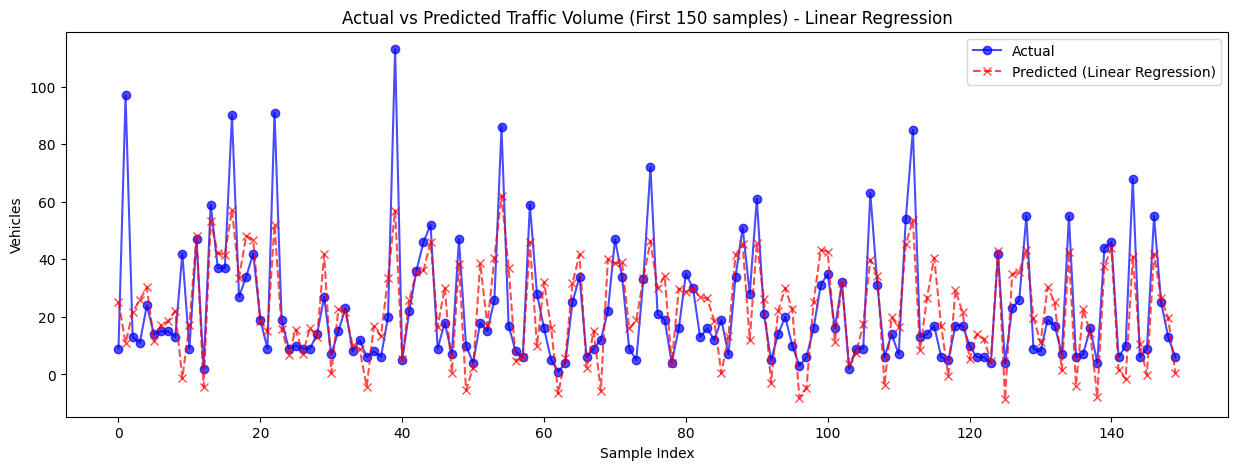

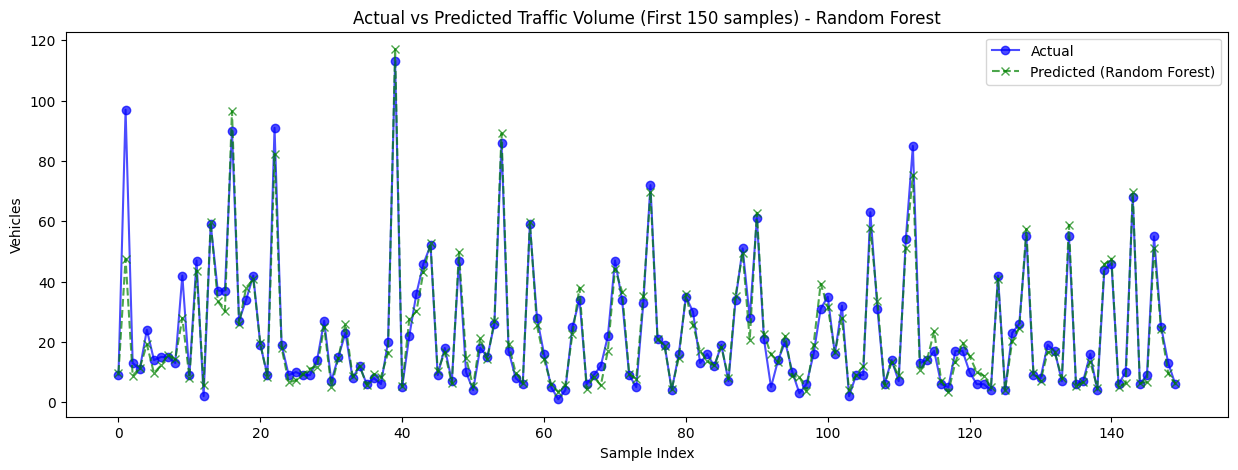

In [7]:
# 1. Plot Actual vs Predicted for Linear Regression
lr_preds = results_dict['Linear Regression']['Predictions']

plt.figure(figsize=(15, 5))
plt.plot(y_test.values[:150], label='Actual', marker='o', linestyle='-', alpha=0.7, color='blue')
plt.plot(lr_preds[:150], label='Predicted (Linear Regression)', marker='x', linestyle='--', alpha=0.7, color='red')
plt.title("Actual vs Predicted Traffic Volume (First 150 samples) - Linear Regression")
plt.xlabel("Sample Index")
plt.ylabel("Vehicles")
plt.legend()
plt.show()

# 2. Plot Actual vs Predicted for Random Forest
rf_preds = results_dict['Random Forest']['Predictions']

plt.figure(figsize=(15, 5))
plt.plot(y_test.values[:150], label='Actual', marker='o', linestyle='-', alpha=0.7, color='blue')
plt.plot(rf_preds[:150], label='Predicted (Random Forest)', marker='x', linestyle='--', alpha=0.7, color='green')
plt.title("Actual vs Predicted Traffic Volume (First 150 samples) - Random Forest")
plt.xlabel("Sample Index")
plt.ylabel("Vehicles")
plt.legend()
plt.show()



### Conclusion

**1. Accuracy / Error Metrics:**
As seen in the results table, Ensemble models (Random Forest, XGBoost) significantly outperformed baseline models including Linear Regression, Ridge, and SVR. SVR performed better than the basic linear models but still struggled compared to tree-based ensembles, primarily because traffic data depends heavily on interactive temporal features. 

**2. Training Time and Computational Complexity:**
Linear models trained almost instantaneously. However, SVR took significantly longer to train (computationally expensive due to its $O(n^2)$ scaling with the number of samples). Ensemble methods, particularly Random Forest, took a moderate amount of time. XGBoost provided the best balance by using parallelized boosting algorithms, achieving top-tier accuracy quickly.

**3. Generalization (Overfitting vs. Underfitting):**
- **Underfitting**: Linear Regression and Ridge Regression underfitted the data, as evidenced by their low R² scores.
- **Overfitting Prevention (Generalization)**: We constrained the Random Forest (`max_depth=15`) to prevent overfitting. XGBoost naturally handles overfitting via regularization parameters. SVR also generalized fairly well but was bottlenecked by its ability to separate complex nonlinear temporal features compared to decision trees.
